In [2]:
##Data Cleaning
userlib <- file.path(Sys.getenv("USERPROFILE"), "Documents", "R", "win-library",
                     paste0(R.version$major, ".", R.version$minor))
dir.create(userlib, recursive = TRUE, showWarnings = FALSE)
.libPaths(c(userlib, .libPaths()))
options(repos = c(CRAN = "https://cloud.r-project.org"))
install.packages("gapminder", type = "binary", dependencies = TRUE)
install.packages("naniar")
install.packages("lmtest")
install.packages("pROC")
install.packages(c("randomForest", "caret", "janitor"))
install.packages("glmnet")
##make sure to run this before using the library 
install.packages(c("tidyverse","rstatix","ggpubr"))
install.packages("gtExtras", repos = c('https://jthomasmock.r-universe.dev', 'https://cloud.r-project.org'))
library(ggpubr)
library(tidyverse)
library(gapminder)
install.packages("dplyr")
library(dplyr)
library(rstatix)
install.packages("kSamples")
library(kSamples)
library(naniar)
library(gtExtras)
library(lmtest)
library(pROC)
library(randomForest)
library(caret)
install.packages("rpart")        # only once
install.packages("rpart.plot")   # optional, for nicer plots
library(rpart)
library(rpart.plot)
library(glmnet)
install.packages("leaps")
library(leaps)

#this is the code to load the dataset

Warning message:
"package 'gapminder' is in use and will not be installed"
Warning message:
"package 'naniar' is in use and will not be installed"
Warning message:
"package 'lmtest' is in use and will not be installed"
Warning message:
"package 'pROC' is in use and will not be installed"
Warning message:
"packages 'randomForest', 'caret' are in use and will not be installed"
Installing package into 'C:/Users/admin/Documents/R/win-library/4.5.2'
(as 'lib' is unspecified)



package 'janitor' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\admin\AppData\Local\Temp\Rtmp6xN92K\downloaded_packages


Warning message:
"package 'glmnet' is in use and will not be installed"
Warning message:
"packages 'tidyverse', 'rstatix', 'ggpubr' are in use and will not be installed"
Warning message:
"package 'gtExtras' is in use and will not be installed"
Warning message:
"package 'dplyr' is in use and will not be installed"
Warning message:
"package 'kSamples' is in use and will not be installed"
Warning message:
"package 'rpart' is in use and will not be installed"
Warning message:
"package 'rpart.plot' is in use and will not be installed"
Warning message:
"package 'leaps' is in use and will not be installed"


In [3]:
df=read.csv("C:/Users/admin/Downloads/train_u6lujuX_CVtuZ9i.csv")
head(df)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate,No,5849,0,NA,360,1,Urban,Y
2,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
3,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
4,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y


In [4]:
num_rows <- nrow(df)
head(df[, 1:5])
print(paste("Number of rows:", num_rows))
num_columns <- ncol(df)
names(df)
print(paste("Number of columns:", num_columns))
cols <- c("Loan_ID","Gender","Married","Dependents","Education","Self_Employed","ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History","Property_Area","Loan_Status")
df[cols] <- lapply(df[cols], function(x) {
  x[x == 0] <- NA
  x
})
df1=na.omit(df)

,Loan_ID,Gender,Married,Dependents,Education
,<chr>,<chr>,<chr>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate
2,LP001003,Male,Yes,1,Graduate
3,LP001005,Male,Yes,0,Graduate
4,LP001006,Male,Yes,0,Not Graduate
5,LP001008,Male,No,0,Graduate
6,LP001011,Male,Yes,2,Graduate


[1] "Number of rows: 614"


[1] "Loan_ID"           "Gender"            "Married"          
 [4] "Dependents"        "Education"         "Self_Employed"    
 [7] "ApplicantIncome"   "CoapplicantIncome" "LoanAmount"       
[10] "Loan_Amount_Term"  "Credit_History"    "Property_Area"    
[13] "Loan_Status"

[1] "Number of columns: 13"


In [5]:
fit_full  <- lm(LoanAmount ~ ., data = df1)
fit_null  <- lm(LoanAmount ~ 1, data = df1)
AIC(fit_full)
logLik(fit_full)

[1] -Inf

'log Lik.' Inf (df=112)

In [6]:
n <- nrow(df1)
fit_full <- lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married , data = df1)
fit_bic <- step(fit_full, direction = "both", k = log(n), trace = 0)
summary(fit_bic)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


In [7]:
fit_full  <- lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married , data = df1)      # all predictors
fit_null  <- lm(LoanAmount ~ 1, data = df1)      # intercept only
# Forward selection (from null up to full) by AIC
fit_fwd <- step(fit_null,scope = formula(fit_full),direction = "forward",trace = 0)
# Backward selection (from full down) by AIC
fit_bwd <- step(fit_full, direction = "backward", trace = 0)
# Both directions (stepwise)
fit_both <- step(fit_full, direction = "both", trace = 0)
summary(fit_both)
formula(fit_both)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


LoanAmount ~ ApplicantIncome

In [101]:
n <- nrow(df1)
fit_full <- lm( LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = df1)
fit_bic <- step(fit_full, direction = "both", k = log(n), trace = 0)
summary(fit_bic)


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-206.188  -31.828   -7.235   20.570  287.379 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.019e+02  1.126e+01   9.047 6.37e-15 ***
ApplicantIncome 1.142e-02  2.157e-03   5.293 6.29e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 63.35 on 109 degrees of freedom
Multiple R-squared:  0.2045,	Adjusted R-squared:  0.1972 
F-statistic: 28.02 on 1 and 109 DF,  p-value: 6.288e-07


In [102]:
regfit <- regsubsets(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = df, nvmax = ncol(df) - 1)
s <- summary(regfit)
s$cp              # Mallows Cp for each best model size
which.min(s$cp)   # model size with smallest Cp
s$which[which.min(s$cp), ]  # which variables are in that model

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"1  linear dependencies found"


Reordering variables and trying again:


[1] 3.71337376 1.54104291 0.07031865 0.86915119 2.59331072 4.44924300 6.32058390
[8] 8.00000000

[1] 3

(Intercept)    GenderFemale      GenderMale     Dependents1     Dependents2 
           TRUE           FALSE            TRUE           FALSE           FALSE 
   Dependents3+ ApplicantIncome  Credit_History       MarriedNo      MarriedYes 
          FALSE            TRUE           FALSE            TRUE           FALSE

In [ ]:
n <- nrow(df)
step(lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, df1), direction="both")         1# AIC
step(lm(LoanAmount~ Gender + Dependents + ApplicantIncome + Credit_History + Married, df1), direction="both", k=log(n))# BIC

Start:  AIC=935.88
LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + 
    Married


Step:  AIC=935.88
LoanAmount ~ Gender + Dependents + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Dependents       3      1287 434371 930.21
- Married          2       782 433865 932.08
- Gender           2      1676 434760 932.31
<none>                         433084 935.88
- ApplicantIncome  1    104663 537747 957.90

Step:  AIC=930.21
LoanAmount ~ Gender + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Married          2       740 435110 926.39
- Gender           2      1882 436253 926.69
<none>                         434371 930.21
+ Dependents       3      1287 433084 935.88
- ApplicantIncome  1    106085 540455 952.46

Step:  AIC=926.39
LoanAmount ~ Gender + ApplicantIncome

                  Df Sum of Sq    RSS    AIC
- Gender           2      2269 437379 922.97
<none>                         435110 926.39
+ Married      


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Coefficients:
    (Intercept)  ApplicantIncome  
      101.85763          0.01142  


Start:  AIC=975.66
LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + 
    Married


Step:  AIC=975.66
LoanAmount ~ Gender + Dependents + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Dependents       3      1287 434371 956.73
- Married          2       782 433865 963.02
- Gender           2      1676 434760 963.24
<none>                         433084 975.66
- ApplicantIncome  1    104663 537747 993.26

Step:  AIC=956.73
LoanAmount ~ Gender + ApplicantIncome + Married

                  Df Sum of Sq    RSS    AIC
- Married          2       740 435110 944.07
- Gender           2      1882 436253 944.37
<none>                         434371 956.73
- ApplicantIncome  1    106085 540455 974.56
+ Dependents       3      1287 433084 975.66

Step:  AIC=944.07
LoanAmount ~ Gender + ApplicantIncome

                  Df Sum of Sq    RSS    AIC
- Gender           2      2269 437379 931.81
<none>                         435110 944.07
+ Married      


Call:
lm(formula = LoanAmount ~ ApplicantIncome, data = df1)

Coefficients:
    (Intercept)  ApplicantIncome  
      101.85763          0.01142  


Warning message:
"not plotting observations with leverage one:
  23, 61"


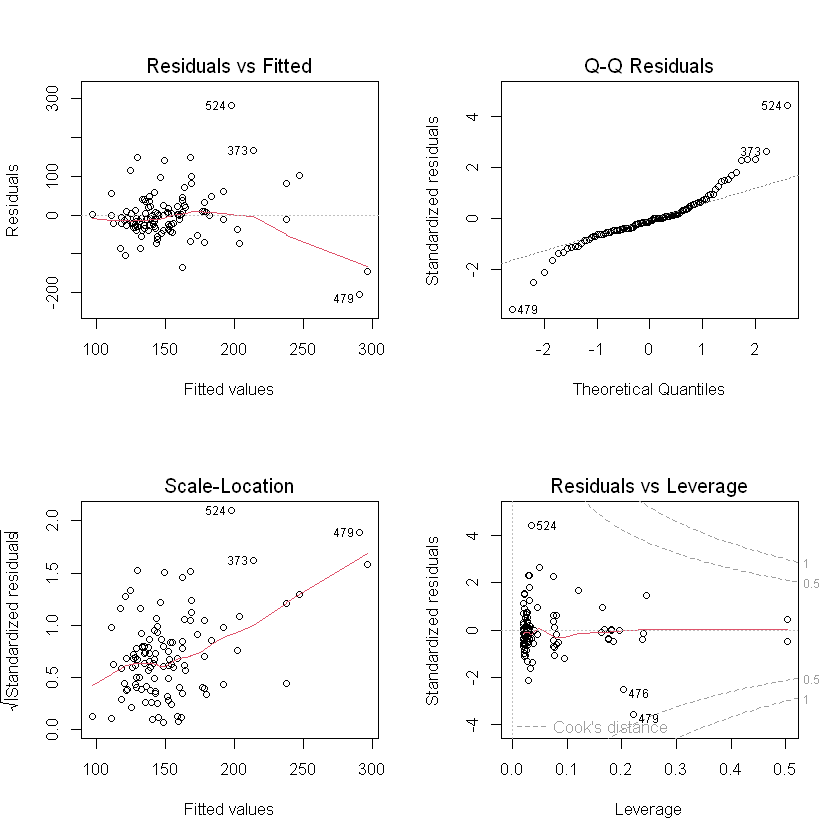

In [103]:
par(mfrow = c(2, 2))
plot(fit_full)
par(mfrow = c(1, 1))

In [92]:
r <- rstandard(fit_full)
f <- fitted(fit_full)
ord <- order(abs(r), decreasing = TRUE)
head(data.frame(row = ord, fitted = f[ord], rstd = r[ord]), 10)
cd <- cooks.distance(fit_full)
head(sort(cd, decreasing = TRUE), 10)

,row,fitted,rstd
,<int>,<dbl>,<dbl>
524,96,197.5669,4.412272
479,84,290.7921,-3.562595
373,72,213.3665,2.622875
476,82,296.1222,-2.511648
254,48,129.8541,2.323387
22,9,167.7043,2.295400
136,28,148.7713,2.254246
556,101,162.1084,-2.119063
418,76,124.6242,1.782469


479        476        524         35        136         10        373 
0.40181127 0.17835963 0.07841588 0.07581533 0.04616014 0.04237016 0.03972365 
       121        302         83 
0.02445955 0.02445955 0.01966998

In [106]:
fit1  <- lm(log(LoanAmount)~ Gender + Dependents + log(ApplicantIncome) + log(Credit_History) + Married , data = df1) 
summary(fit1)


Call:
lm(formula = log(LoanAmount) ~ Gender + Dependents + log(ApplicantIncome) + 
    log(Credit_History) + Married, data = df1)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.78837 -0.17189  0.04033  0.21082  0.94128 

Coefficients: (1 not defined because of singularities)
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           1.738233   0.948573   1.832   0.0698 .  
GenderFemale          0.211812   0.497385   0.426   0.6711    
GenderMale            0.074596   0.453955   0.164   0.8698    
Dependents1           0.002924   0.320549   0.009   0.9927    
Dependents2           0.041012   0.318462   0.129   0.8978    
Dependents3+          0.042012   0.334880   0.125   0.9004    
log(ApplicantIncome)  0.395582   0.076851   5.147 1.29e-06 ***
log(Credit_History)         NA         NA      NA       NA    
MarriedNo            -0.289289   0.571215  -0.506   0.6136    
MarriedYes           -0.173929   0.540955  -0.322   0.7485    
---
Signif. code

Warning message:
"not plotting observations with leverage one:
  23, 61"


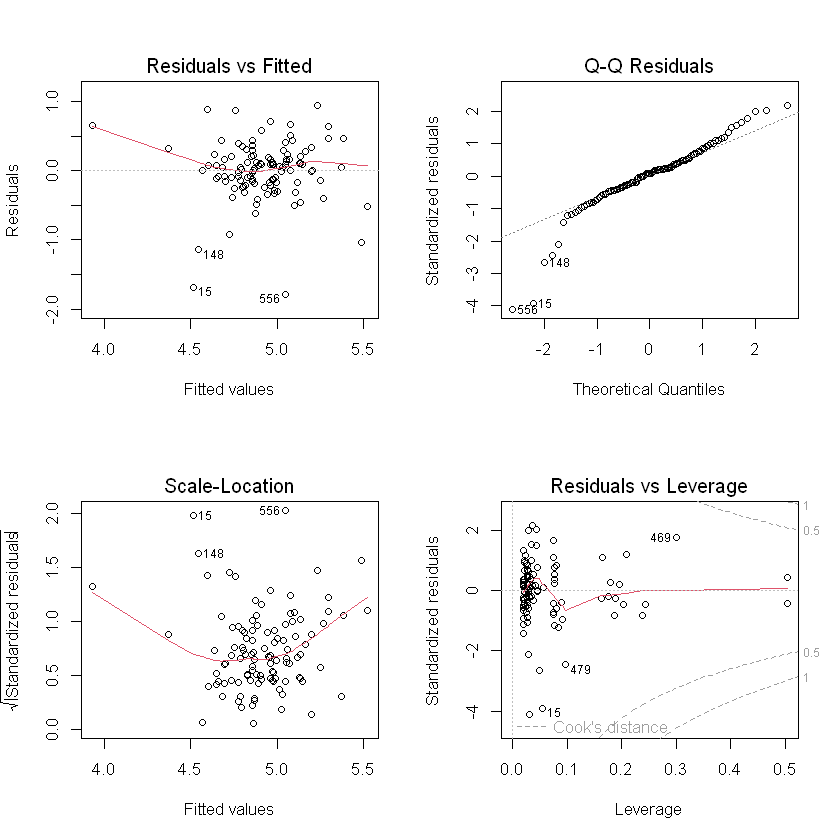

In [107]:
par(mfrow=c(2,2)); plot(fit1); par(mfrow=c(1,1))

In [ ]:
set.seed(1)
idx <- sample(seq_len(nrow(df1)), size = floor(0.8 * nrow(df1)))
train <- df1[idx, ]
test  <- df1[-idx, ]
fit <- lm(LoanAmount ~ Gender + Dependents + ApplicantIncome + Credit_History + Married, data = train)
pred <- predict(fit, newdata = test)

rmse <- sqrt(mean((test$LoanAmount - pred)^2))
rmse

ERROR: Error: object 'idx' not found
